<a href="https://colab.research.google.com/github/LetheeshBalaji/24ADI003-24BAD063/blob/main/fraud_smote.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE

**Load data**

In [4]:
df = pd.read_csv("fraud_smote.csv")
df.head()

,Amount,Time,Feature1,Feature2,Fraud
0,3233.38,34595,2.157308,-0.818199,0
1,2783.63,73166,1.561511,0.955305,0
2,923.74,84417,-0.027305,-1.418366,0
3,2214.14,11139,-0.643518,-0.466037,0
4,444.75,37847,0.021272,-0.529053,0


Data Preprocessing

In [5]:
df.isnull().sum()

,0
Amount,0
Time,0
Feature1,0
Feature2,0
Fraud,0


In [6]:

print(df["Fraud"].value_counts())

Fraud
0    110
1     10
Name: count, dtype: int64


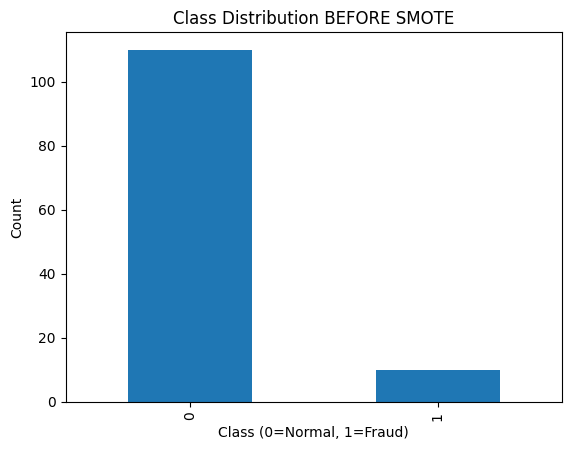

In [7]:

plt.figure()
df["Fraud"].value_counts().plot(kind='bar')
plt.title("Class Distribution BEFORE SMOTE")
plt.xlabel("Class (0=Normal, 1=Fraud)")
plt.ylabel("Count")
plt.show()

In [8]:
X = df.drop("Fraud", axis=1)
y = df["Fraud"]

In [9]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:

from sklearn.ensemble import RandomForestClassifier

In [14]:
model_before = RandomForestClassifier(n_estimators=100, random_state=42)
model_before.fit(X_train, y_train)

y_pred_before = model_before.predict(X_test)

In [15]:
print("\n--- Before SMOTE ---")
print(classification_report(y_test, y_pred_before))


--- Before SMOTE ---
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       0.00      0.00      0.00         2

    accuracy                           0.92        24
   macro avg       0.46      0.50      0.48        24
weighted avg       0.84      0.92      0.88        24



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Apply somte**

In [16]:

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [17]:
print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())


After SMOTE:
Fraud
1    88
0    88
Name: count, dtype: int64


**Train model after smote**


In [18]:
model_after = RandomForestClassifier(n_estimators=100, random_state=42)
model_after.fit(X_train_sm, y_train_sm)

RandomForestClassifier(random_state=42)

In [19]:

y_pred_after = model_after.predict(X_test)

print("\n--- After SMOTE ---")
print(classification_report(y_test, y_pred_after))


--- After SMOTE ---
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        22
           1       0.00      0.00      0.00         2

    accuracy                           0.83        24
   macro avg       0.45      0.45      0.45        24
weighted avg       0.83      0.83      0.83        24



Class distribution after smote

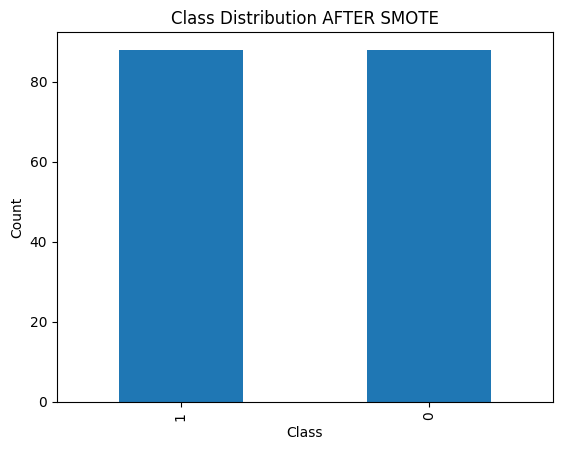

In [20]:
plt.figure()
pd.Series(y_train_sm).value_counts().plot(kind='bar')
plt.title("Class Distribution AFTER SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Precison recall curve

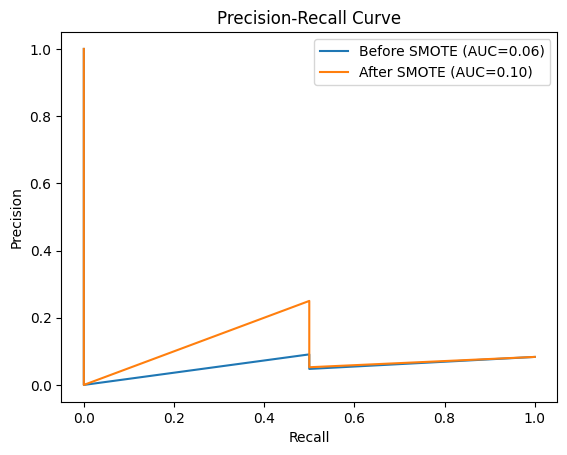

In [22]:
y_prob_before = model_before.predict_proba(X_test)[:, 1]
y_prob_after = model_after.predict_proba(X_test)[:, 1]

precision_b, recall_b, _ = precision_recall_curve(y_test, y_prob_before)
precision_a, recall_a, _ = precision_recall_curve(y_test, y_prob_after)

pr_auc_before = auc(recall_b, precision_b)
pr_auc_after = auc(recall_a, precision_a)

plt.figure()
plt.plot(recall_b, precision_b, label=f"Before SMOTE (AUC={pr_auc_before:.2f})")
plt.plot(recall_a, precision_a, label=f"After SMOTE (AUC={pr_auc_after:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()